In [32]:
import os
import numpy as np
import pandas as pd
import matplotlib as mp
import matplotlib.pyplot as plt
import seaborn as sns


data = pd.read_csv("./seguro.csv")

In [33]:
# Renombramos los nombres de las columnas para poder hacer referencias a ellas sin los corchetes, como si fuesen propiedades

# [print(col) for col in data.columns]
data = data.rename(columns={"Edad conductor":"Edad_conductor",
                            "Experiencia conductor":"Experiencia_conductor",
                            "Accidentes previos":"Accidentes_previos",
                            "Kilometraje anual":"Kilometraje_anual",
                            "Fabricacion coche":"Fabricacion_coche",
                            "Edad coche":"Edad_coche",
                            "Seguro Premium":"Seguro_Premium"})

# [print(col) for col in data.columns]

In [34]:
filas, columnas = data.shape
print(f"Nº Filas: {filas} - Nº Columnas: {columnas}")
nom_cols = data.columns.tolist()

Nº Filas: 1000 - Nº Columnas: 8


**Limpieza de nulos**

In [35]:
print(data.isna().value_counts())
print("\n** no tenemos nulos **")

Edad_conductor  Experiencia_conductor  Accidentes_previos  Kilometraje_anual  Fabricacion_coche  Edad_coche  Seguro_Premium  Sexo 
False           False                  False               False              False              False       False           False    1000
Name: count, dtype: int64

** no tenemos nulos **


**Generamos columna Accidentado Si/No y creamos df_virtuosos**

In [36]:
data["Accidentado"] = np.where(data.Accidentes_previos > 0, "Si", "No")
virtuosos = data.Accidentes_previos == 0
df_virtuosos = pd.DataFrame()

for i in nom_cols:
    if i != "Accidentes_Previos" and i != "Accidentado":
        df_virtuosos[i] = data[i][virtuosos]
        
print(df_virtuosos.shape)
display(df_virtuosos.head())

(154, 8)


,Edad_conductor,Experiencia_conductor,Accidentes_previos,Kilometraje_anual,Fabricacion_coche,Edad_coche,Seguro_Premium,Sexo
846,46,19,0,21,2025,0,486.15,Hombre
847,25,7,0,13,2005,20,495.55,Hombre
848,41,1,0,19,2007,18,494.25,Hombre
849,19,1,0,16,2010,15,498.20,Hombre
850,29,8,0,22,2025,0,492.90,Mujer


**Añadimos a df_virtuosos la columna coste/experiencia**

In [37]:
df_virtuosos["coste_experiencia"]=np.where(df_virtuosos.Experiencia_conductor > 0,
                                           df_virtuosos.Seguro_Premium/df_virtuosos.Experiencia_conductor,
                                           1/df_virtuosos.Experiencia_conductor)
df_virtuosos.coste_experiencia = df_virtuosos.coste_experiencia.round(2)

display(df_virtuosos)

,Edad_conductor,Experiencia_conductor,Accidentes_previos,Kilometraje_anual,Fabricacion_coche,Edad_coche,Seguro_Premium,Sexo,coste_experiencia
846,46,19,0,21,2025,0,486.15,Hombre,25.59
847,25,7,0,13,2005,20,495.55,Hombre,70.79
848,41,1,0,19,2007,18,494.25,Hombre,494.25
849,19,1,0,16,2010,15,498.20,Hombre,498.20
850,29,8,0,22,2025,0,492.90,Mujer,61.61
...,...,...,...,...,...,...,...,...,...
995,23,5,0,18,2009,16,496.40,Hombre,99.28
996,48,25,0,25,2002,23,486.45,Mujer,19.46
997,54,29,0,24,2025,0,481.70,Mujer,16.61
998,23,5,0,16,2000,25,497.20,Hombre,99.44


In [38]:
display(data.describe())
display(data.head(5))

,Edad_conductor,Experiencia_conductor,Accidentes_previos,Kilometraje_anual,Fabricacion_coche,Edad_coche,Seguro_Premium
count,1000.000000,1000.000000,1000.0000,1000.000000,1000.000000,1000.000000,1000.000000
mean,41.575000,14.759000,2.5680,17.933000,2007.637000,17.363000,493.742250
std,13.765677,10.544292,1.6989,4.410665,10.363331,10.363331,5.909689
min,18.000000,0.000000,0.0000,11.000000,1990.000000,0.000000,477.050000
25%,30.000000,6.000000,1.0000,14.000000,1999.000000,8.000000,489.487500
50%,42.000000,13.000000,3.0000,18.000000,2008.000000,17.000000,493.950000
75%,53.000000,23.000000,4.0000,22.000000,2017.000000,26.000000,498.312500
max,65.000000,40.000000,5.0000,25.000000,2025.000000,35.000000,508.150000


,Edad_conductor,Experiencia_conductor,Accidentes_previos,Kilometraje_anual,Fabricacion_coche,Edad_coche,Seguro_Premium,Sexo,Accidentado
0,28,10,5,12,2022,3,499.80,Mujer,Si
1,28,10,5,20,2025,0,499.90,Hombre,Si
2,53,32,5,24,2023,2,488.70,Hombre,Si
3,41,9,5,13,2013,12,498.45,Hombre,Si
4,38,0,5,13,2017,8,501.35,Mujer,Si


# Consultas

In [39]:
si = data.Accidentado=="Si"
si, no = si.value_counts()

print(f"Accidentados: {si/10}%")
print(f"NO accidentados: {no/10}%")
print("-"*50)

h = data.Sexo == "Hombre"
h, m = h.value_counts()

print(f"Experiencia media Hombres: {data.Experiencia_conductor[h].mean()}")
print(f"Experiencia media Hombres: {data.Experiencia_conductor[m].mean()}")
print(f"Experiencia media Hombres: {data.Experiencia_conductor.mean()}")
print("-"*50)




Accidentados: 84.6%
NO accidentados: 15.4%
--------------------------------------------------
Experiencia media Hombres: 0.0
Experiencia media Hombres: 15.0
Experiencia media Hombres: 14.759
--------------------------------------------------


** Faltan 3,4,5,6 **

## Gráficos

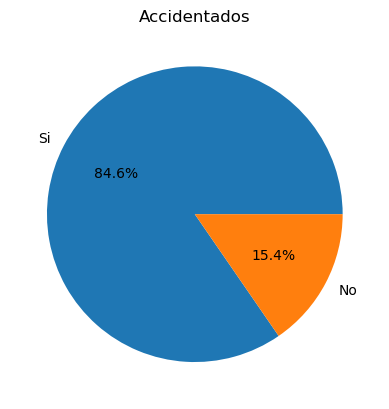

In [40]:
plt.pie(data.Accidentado.value_counts(),labels=data.Accidentado.value_counts().index, autopct='%1.1f%%')
plt.title("Accidentados")
plt.show()

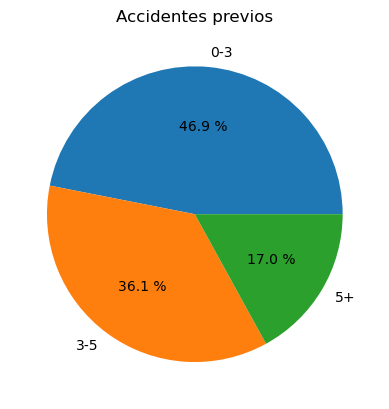

In [41]:
cat1 = data.Accidentes_previos[data.Accidentes_previos < 3]
cat2 = data.Accidentes_previos[(data.Accidentes_previos >= 3) & (data.Accidentes_previos < 5)]
cat3 = data.Accidentes_previos[data.Accidentes_previos >= 5]

plt.pie([cat1.__len__(),cat2.__len__(),cat3.__len__()],labels=["0-3", "3-5", "5+"], autopct="%0.1f %%")
plt.title("Accidentes previos")
plt.show()

**Histograma**  
Podemos ver que los precios de los seguros rondan entre algo menos de los 490€ y algo más 500€ mayoritariamente. Con una leve cola a izquierdas que muestra que hay una progresión más lenta (más repartido) del precio más barato a la mediana que de esta al más caro.

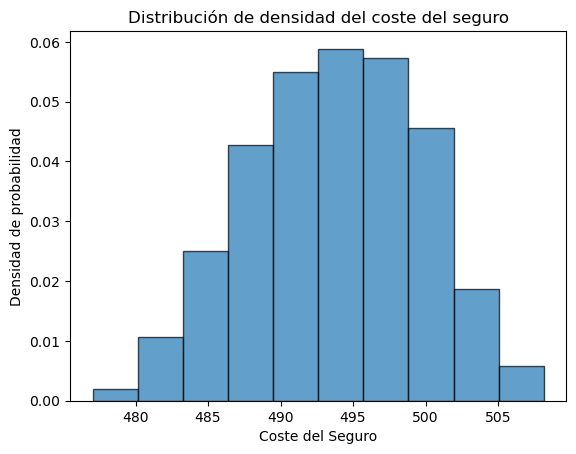

In [42]:
plt.hist(data['Seguro_Premium'], bins=10, density=True, edgecolor='black', alpha=0.7)
plt.xlabel('Coste del Seguro')
plt.ylabel('Densidad de probabilidad')
plt.title('Distribución de densidad del coste del seguro')
plt.show()

**Nube de puntos**  
Se puede observar que hay una correlación inversa entre el precio y la edad tanto en hombres como en mujeres. Aunque esta es más dispersa a medida que la edad va en aumento. De lo que se puede intuir que a medida que las personas, tanto hombres como mujeres, cumplen edad, estos tendrán presumiblemente más accidentes y esto les repercute en el precio del seguro.

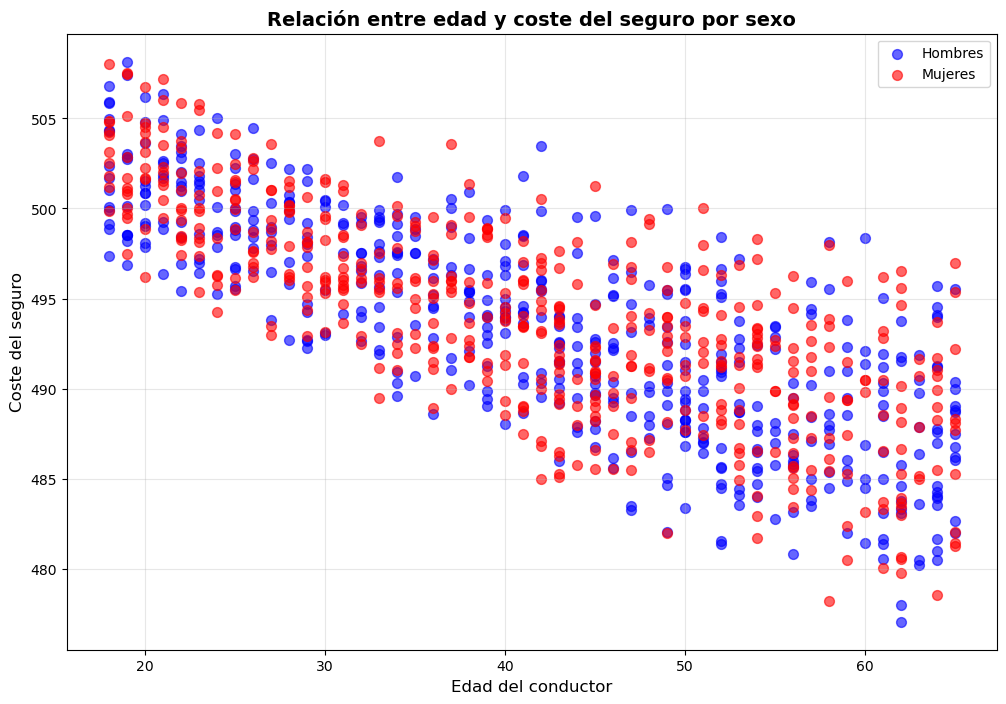

In [43]:
h = data[data['Sexo'] == 'Hombre']
m = data[data['Sexo'] == 'Mujer']

plt.figure(figsize=(12, 8))

plt.scatter(h['Edad_conductor'], h['Seguro_Premium'], 
            color='blue', alpha=0.6, label='Hombres', s=50)

# Puntos para mujeres
plt.scatter(m['Edad_conductor'], m['Seguro_Premium'], 
            color='red', alpha=0.6, label='Mujeres', s=50)

plt.xlabel('Edad del conductor', fontsize=12)
plt.ylabel('Coste del seguro', fontsize=12)
plt.title('Relación entre edad y coste del seguro por sexo', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Conversión de variables

In [44]:
data_num = data
data_num["Accidentado"] = np.where(data.Accidentado == "Si",1,0)
data_num["Sexo"] = np.where(data.Sexo == "Hombre",1,0)

**Correlación**
Podemos ver que hay dos correlaciones bastante directas entre las variables:
- Edad_conductor y el coste del seguro
- Experiencia del conductor y el coste del seguro

Podemos pensar que el coste del seguro depende en gran medida de la experiencia y la edad del conductor. Aunque también deberíamos de tener en cuenta los accidentes previos, que aunque no tengan una relación tan directa, si parece matizar el precio final.  
  
Parece que la relación menor sería entre el sexo del conductor, los accidentes previos y el kilometraje anual.

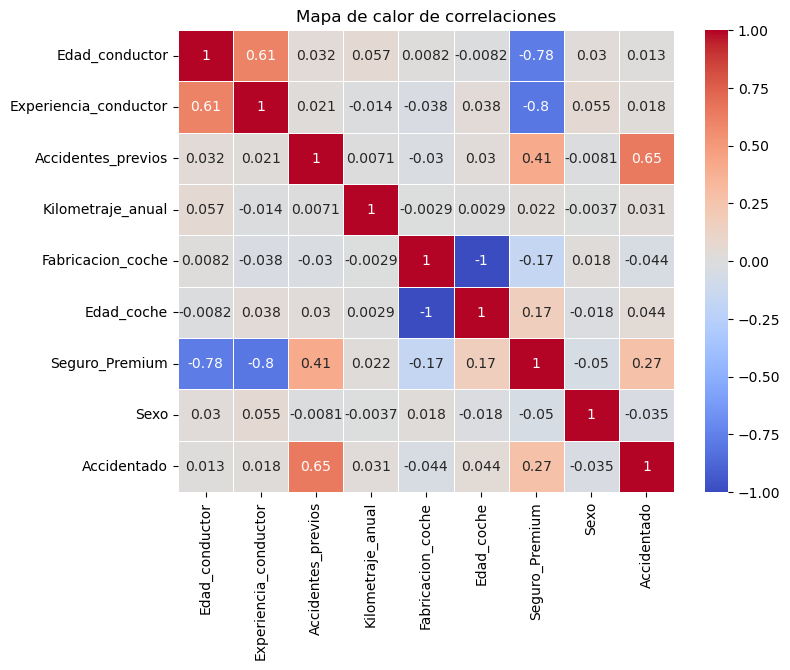

In [45]:
# Crea la matriz de correlación
corr_matrix = data_num.corr(numeric_only=True)    # Sólo se aplica a columnas numéricas

# Genera un mapa de calor de correlaciones
plt.figure(figsize=(8, 6))      # Marco de 8x6 pulgadas
sns.heatmap(corr_matrix,        # Mapa de calor generado con Seaborn
            annot=True,         # Muestra el valor (coef. de Pearson) en cada celda
            cmap='coolwarm',    # Mapea los valores a tonos azules (-) y rojos (+)
            linewidths=0.5)     # Ancho de las líneas de separación de celdas

plt.title("Mapa de calor de correlaciones")

plt.show()